## Pre-turtorial steps:
### [AGB 100m Dataset in Earthmover](https://app.earthmover.io/marketplace/69e00e1c21faca8bf36879d2)


*   If you or your company do not have an Earthmvover account:
    *   Sign up for free by clicking [Get Started!](https://app.earthmover.io/)!
    *   Create or connect to **organization** (individual just exploring? Name organization anything unique to you!)

* Select "subscribe" to [repository](https://app.earthmover.io/marketplace/69e00e1c21faca8bf36879d2) and name it what you feel most fit!
    *  Subscribing adds this dataset to your organization as a repository. No data is copied — you'll access it directly through the Arraylake Python client or web UI.
*  **Keep note of your organization and repository name, you will need them to walk through the code below!!**

# CTrees' Above Ground Biomass Data Access Tutorial — Summary

This tutorial shows how to access, visualize, and analyze global 100m Above Ground Biomass (AGB) data from CTrees using Arraylake and Python in Google Colab. Click the hidden cells to see more details, or get started by running them to install the pip dependencies!


**What you do in this tutorial:**

1. **Set up the environment**
   - Install required Python packages: `rioxarray`, `arraylake`, etc.
   - Import libraries: NumPy, pandas, GeoPandas, xarray, Arraylake `Client`, and rioxarray.
   - Log into Arraylake with `Client().login()` to read data from the cloud.

2. **Load the global AGB dataset**
   - Connect to the `ctrees/agb_100m_global` repository.
   - Open the `aboveground_biomass` Icechunk dataset with xarray.
   - Inspect the `agb` variable:
     - `time` dimension: years 2000-2025.
     - `x` and `y` dimensions: global grid coverage.
     - Metadata: projection (spatial reference), units, and scale factor.

3. **Clip data by a bounding box (WGS84)**
   - Define a bounding box `[minx, miny, maxx, maxy]`.
   - Subset `ds.agb` to that region.
   - Plot biomass maps for selected years (e.g., 2020 and 2025).

4. **Export a single year as a GeoTIFF**
   - Select a specific year from the clipped data.
   - Save as a GeoTIFF with `rioxarray` (`.rio.to_raster()`).
   - Download the GeoTIFF from the Colab “Files” panel.

5. **Clip data by a geometry (e.g., admin boundary)**
   - Load a polygon geometry (e.g., GeoJSON) with GeoPandas.
   - Use the geometry’s bounds to crop the raster.
   - Clip the raster to the polygon using `rio.clip`.
   - Plot biomass for the geometry for different years.

6. **Compute and plot time-series statistics**
   - Clean the data:
     - Mask no-data values (e.g., `-9999`).
     - Set negative values to 0.
     - Apply the scale factor (e.g., divide by 10).
   - Compute average AGB density over the clipped area for all years.
   - Convert results to a pandas DataFrame.
   - Plot a time series of `avg_agb_density` vs. `time`.

Overall, the notebook guides you through a complete workflow:
**log in → load global AGB → subset (bounding box or polygon) → visualize → export → compute + plot time-series statistics** for Above Ground Biomass.

#### Pip install dependencies then **restart session**
*after session has restarted, skip this line!*

In [ ]:
! pip install rioxarray arraylake==1.0.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 21.2 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0
  Attempting uninstall: xarray
    Found existing in

# Connect to Arraylake


*   Import dependencies
*   Log into Arraylake to read data from the cloud. *Note: You will need to copy and paste url into new tab which is given from running client.login().*



In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
from arraylake import Client
import rioxarray as rio

## Copy and paste link below into url and click "Confirm"

In [ ]:
client = Client()
client.login()

## ⚠ Update Organization and Dataset Name to what you called your dataset in Arraylake!

In [ ]:
ORGANIZATION_NAME = "ctrees" ## your organizaiton name
REPOSITORY_NAME = "aboveground_biomass_100m_global" ## what you decided to call the dataset!

# View FULL AGB Dataset

In [ ]:
repo = client.get_repo(f"{ORGANIZATION_NAME}/{REPOSITORY_NAME}")
session = repo.readonly_session(branch="main")
ds = xr.open_zarr(session.store, zarr_format=3, group="aboveground_biomass")
ds

<xarray.Dataset> Size: 9TB
Dimensions:      (time: 26, y: 202500, x: 405000)
Coordinates:
  * time         (time) datetime64[D] 208B 2000-01-01 2001-01-01 ... 2025-01-01
  * y            (y) float64 2MB 90.0 90.0 90.0 90.0 ... -90.0 -90.0 -90.0 -90.0
  * x            (x) float64 3MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref  int64 8B ...
Data variables:
    agb          (time, y, x) float32 9TB dask.array<chunksize=(1, 2000, 2000), meta=np.ndarray>

## Take a closer look into the "agb" variable

*   The time dimension tells you that this dataset goes from 2000-2025
*   The x & y dimension tell you this is a global dataset
*   The spatial ref tells you the projection system the data is in
*   The attributes tells you the units
*   There is a scale factor of 10


In [ ]:
ds.agb

<xarray.DataArray 'agb' (time: 26, y: 202500, x: 405000)> Size: 9TB
dask.array<open_dataset-agb, shape=(26, 202500, 405000), dtype=float32, chunksize=(1, 2000, 2000), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[D] 208B 2000-01-01 2001-01-01 ... 2025-01-01
  * y            (y) float64 2MB 90.0 90.0 90.0 90.0 ... -90.0 -90.0 -90.0 -90.0
  * x            (x) float64 3MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref  int64 8B ...
Attributes:
    AREA_OR_POINT:     Area
    long_name:         Above Ground Biomass
    dtype:             int16
    valid_min:         0
    valid_max:         6000
    units:             Mg ha-1
    agb_scale_factor:  10

# View clipped AGB Dataset

* Let's find a [bounding box](https://bboxfinder.com/) to look closer at the data! Replace the `bbox` below with your choice of WGS84 coordinates

In [ ]:
bbox = [-77.124023,-1.318243,-75.454102,-0.357053]

In [ ]:
minx, miny, maxx, maxy = bbox

da_clip = ds.agb.sel(
    x=slice(minx, maxx),
    y=slice(maxy, miny),
) / ds.agb.attrs.get("agb_scale_factor")

## Let's plot a few years!

In [ ]:
year_one = 2000
year_two = 2003

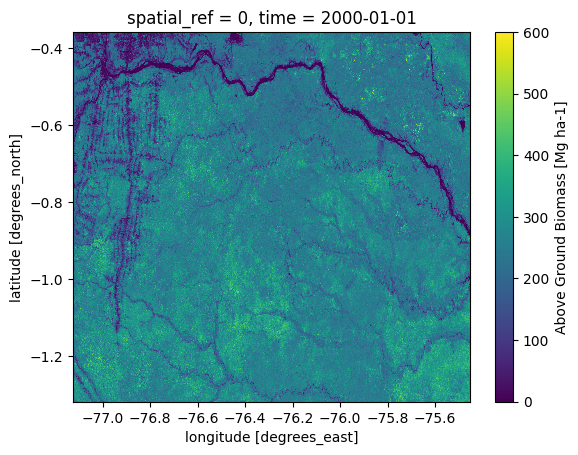

In [ ]:
da_clip.sel(time=f"{year_one}-01-01").plot()


2003


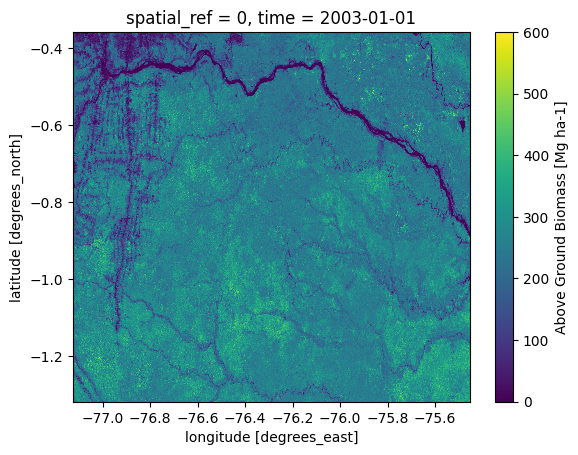

In [ ]:
print(year_two)
da_clip.sel(time=f"{year_two}-01-01").plot()

## What if we wanted to save the output as a geotiff?

In [ ]:
da_year = da_clip.sel(time=f"{year_one}-01-01")

da_year.rio.to_raster(f"my_bbox_{year_one}-01-01.tif",
    tiled=True,       # better layout for partial reads
    windowed=True,    # avoids loading everything into memory at once
    compress="LZW",
)

## And then download it to our computer?! Select the "files" button the left, and you shoudl be able to "download" the file from there!

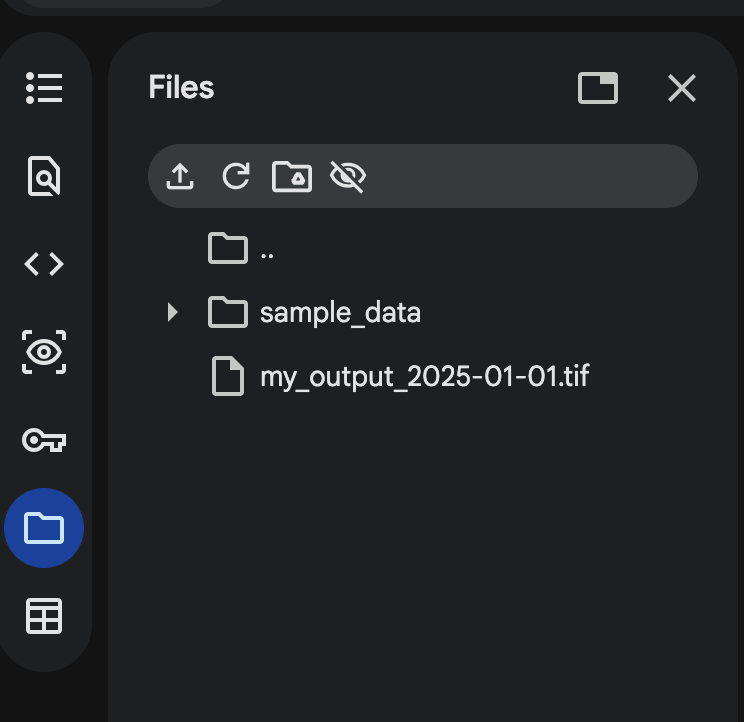

# What if we wanted to plot a geometry?
1. upload geometry to that "files" folder you just downloaded the geotiff from
2. rename "file_name" to your geometry file name, and run the section below!

In [ ]:
file_name = "https://ctrees-website.s3.us-west-2.amazonaws.com/gis_administrative_boundaries/GADM_v41/admin_2/USA/GADM41_USA.5.19_1.geojson"

<Axes: >

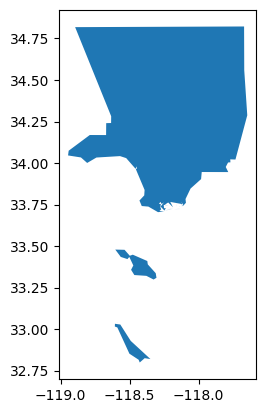

In [ ]:
# --- Load geometries ---
gdf = gpd.read_file(file_name)
gdf.geometry.plot()

In [ ]:
geom = gdf.geometry
minx, miny, maxx, maxy = geom.total_bounds

# Keep all years, but crop spatially before clipping to the polygon.
da_clip = ds.agb.sel(
    x=slice(minx, maxx),
    y=slice(maxy, miny),
) / ds.agb.attrs.get("agb_scale_factor")

da_masked = da_clip.rio.clip(geom, crs="EPSG:4326", drop=True)

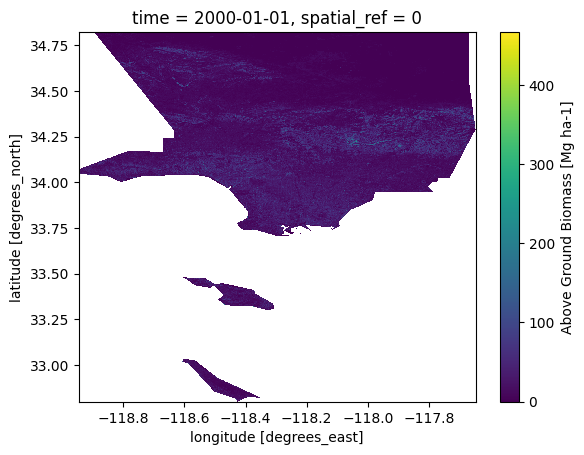

In [ ]:
da_masked.sel(time=f"{year_one}-01-01").plot()

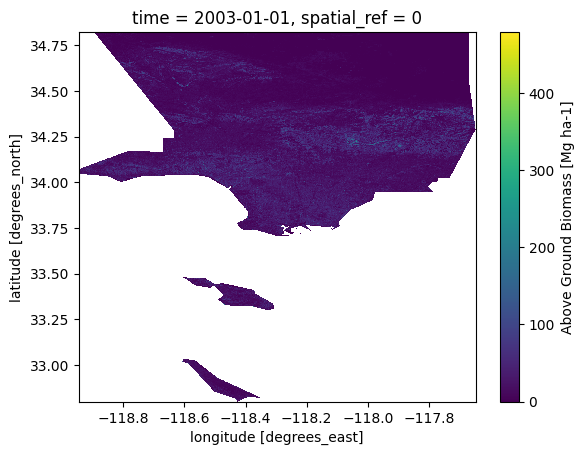

In [ ]:
da_masked.sel(time=f"{year_two}-01-01").plot()

## Find AGB values for all years for clipped geometry!

In [ ]:
# Define no_data_val and apply masking
no_data_val = -9999

# Apply masking for no_data_val and negatives, then scale
cleaned = da_masked.where(da_masked != no_data_val)  # Mask no_data_val
cleaned = cleaned.where(cleaned > 0, 0)

# Compute total and average AGB for all years at once
stats_df = xr.Dataset(
    data_vars={
        "avg_agb_density": cleaned.mean(dim=("y", "x"), skipna=True).fillna(0),
    }
)

# Convert to pandas DataFrame if needed
stats_df = stats_df.to_dataframe().reset_index()

<Axes: title={'center': 'Average Above Ground Biomass Density'}, xlabel='time'>

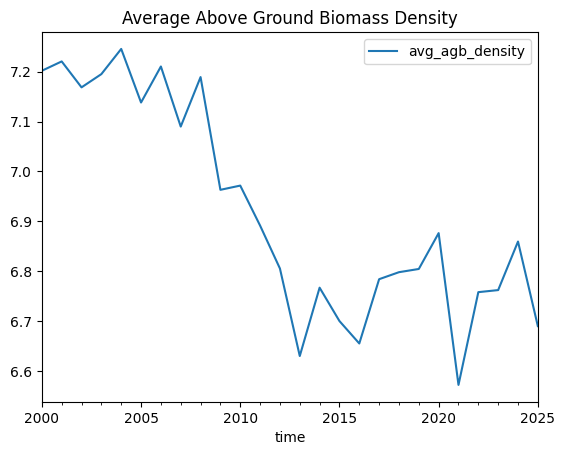

In [ ]:
## plot & download time sereis
stats_df.plot(x="time", y="avg_agb_density", title="Average Above Ground Biomass Density")

In [ ]:
stats_df

,time,spatial_ref,avg_agb_density
0,2000-01-01,0,7.201921
1,2001-01-01,0,7.220662
2,2002-01-01,0,7.168657
3,2003-01-01,0,7.195221
4,2004-01-01,0,7.245728
5,2005-01-01,0,7.138275
6,2006-01-01,0,7.210509
7,2007-01-01,0,7.090014
8,2008-01-01,0,7.189278
9,2009-01-01,0,6.963176
